# **Heart Disease Prediction**

Importing Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import joblib as jb

Load Dataset

In [61]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Dataset Inspection

In [62]:
df.shape

(918, 12)

In [63]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [64]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [65]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


Exploratory Data Analysis

<Axes: xlabel='HeartDisease', ylabel='count'>

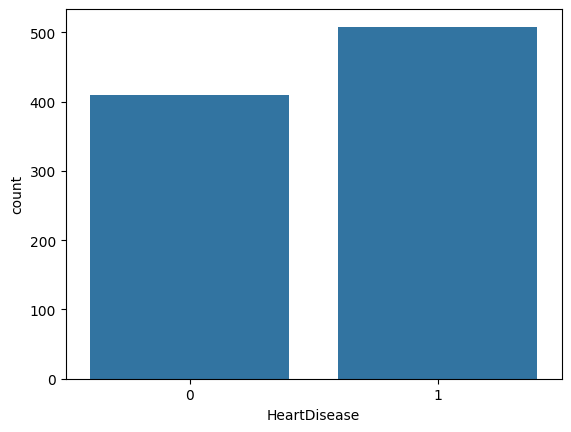

In [68]:
sns.barplot(df["HeartDisease"].value_counts())

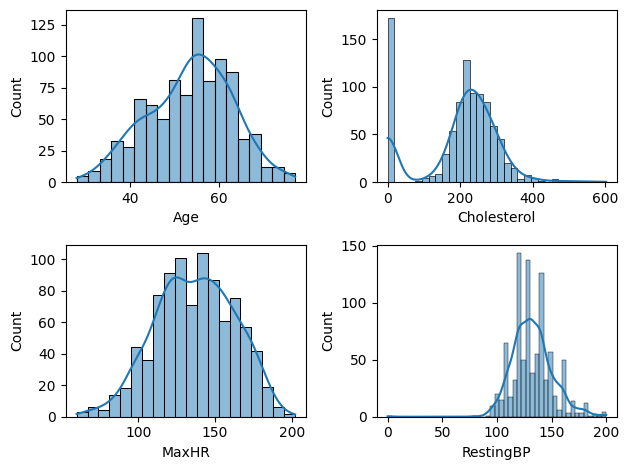

In [69]:
def plotting(var, n):
  plt.subplot(2, 2, n)
  sns.histplot(df[var], kde=True)

plotting("Age", 1)
plotting("Cholesterol", 2)
plotting("MaxHR", 3)
plotting("RestingBP", 4)

plt.tight_layout()

In [70]:
df["Cholesterol"].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [71]:
ch_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
ch_mean

np.float64(244.6353887399464)

In [72]:
df["Cholesterol"] = df["Cholesterol"].replace(0, ch_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)

In [73]:
rbp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()
rbp_mean

np.float64(132.54089422028352)

In [74]:
df["RestingBP"] = df["RestingBP"].replace(0, rbp_mean)
df["RestingBP"] = df["RestingBP"].round(2)

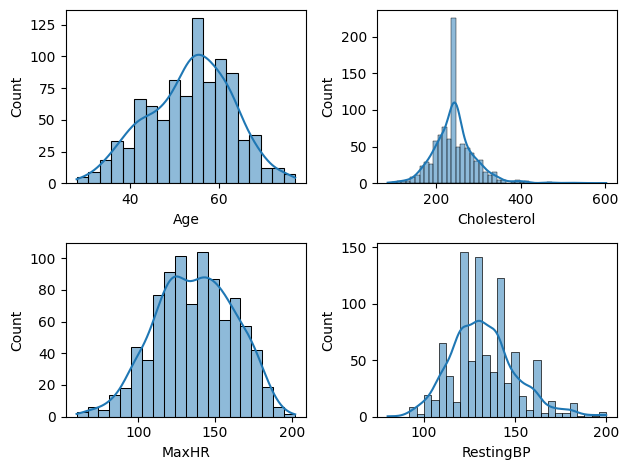

In [75]:
plotting("Age", 1)
plotting("Cholesterol", 2)
plotting("MaxHR", 3)
plotting("RestingBP", 4)
plt.tight_layout()

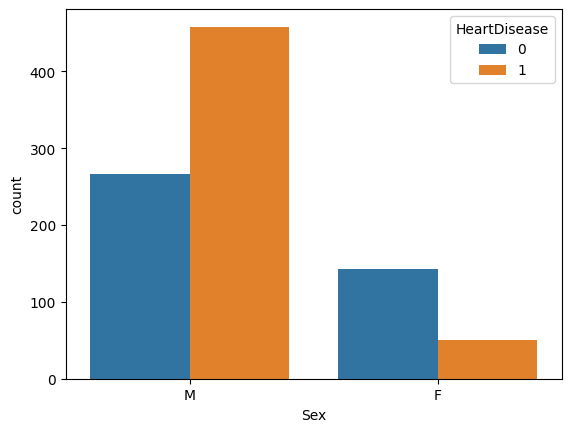

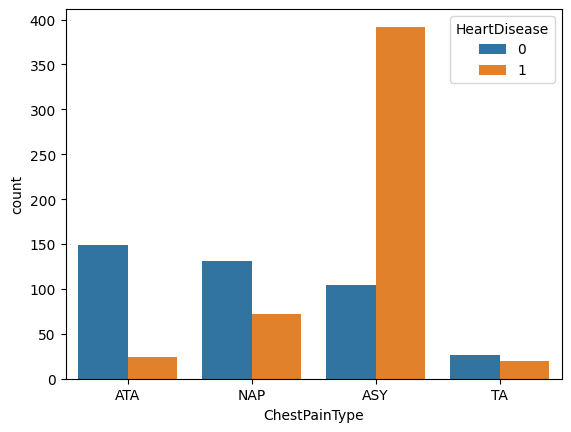

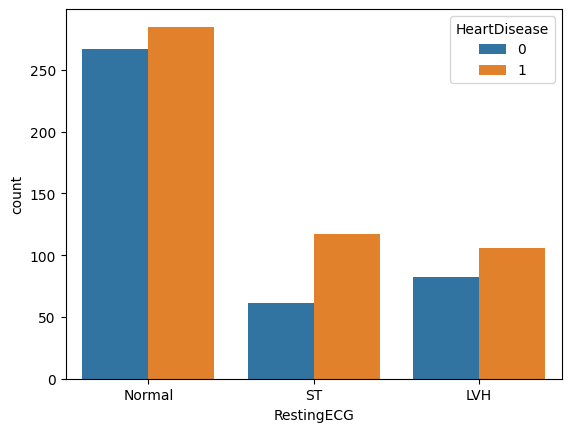

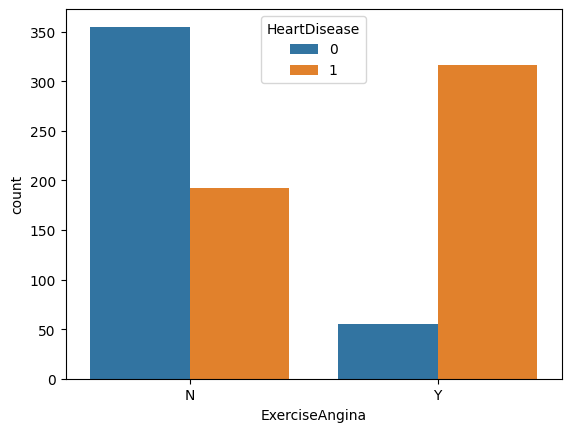

In [76]:
def cat_val_plot(var):
  sns.countplot(data=df, x=var, hue="HeartDisease")
  plt.show()

cat_val_plot("Sex")
cat_val_plot("ChestPainType")
cat_val_plot("RestingECG")
cat_val_plot("ExerciseAngina")

<Axes: >

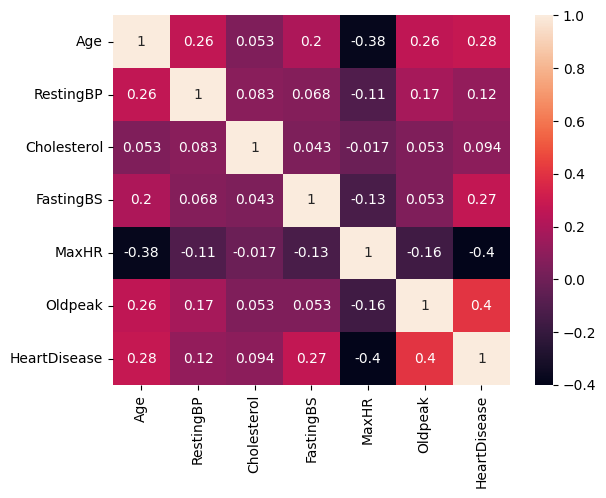

In [77]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Train-Test Split

In [78]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [79]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((734, 11), (184, 11), (734,), (184,))

Preprocessing

In [80]:
num_cols = X.select_dtypes(include=np.number).columns
num_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')

In [81]:
cat_cols = X.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [82]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop="first")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

Model Training, Predicting and Evaluation

In [83]:
def model_eval(model):
  pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
  )
  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)
  print(f"Model: {model}")
  accuracy = pipeline.score(X_test, y_test)
  print(f"Accuracy: {accuracy*100:.4f}%")
  f1 = f1_score(y_test, y_pred)
  print(f"F1 Score: {f1:.4f}")
  report = classification_report(y_test, y_pred)
  print(report)
  con_mat = confusion_matrix(y_test, y_pred)
  print(con_mat)

In [84]:
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(kernel="rbf"),
    "Naive Bayes": GaussianNB()
}

for name, current_model in models.items():
  print(f"Evaluating {name}:")
  model_eval(current_model)
  print("-" * 30)

Evaluating Logistic Regression:
Model: LogisticRegression()
Accuracy: 86.9565%
F1 Score: 0.8846
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

[[68  9]
 [15 92]]
------------------------------
Evaluating K-Nearest Neighbors:
Model: KNeighborsClassifier(n_neighbors=3)
Accuracy: 85.3261%
F1 Score: 0.8683
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        77
           1       0.91      0.83      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

[[68  9]
 [18 89]]
------------------------------
Evaluating Decision Tree:
Model: Decisi

Final Random Forest Model Pipeline for Deployment

In [86]:
final_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", models["Random Forest"])
    ]
)

final_rf_pipeline.fit(X_train, y_train)

jb.dump(final_rf_pipeline, "RF_model.pkl")

jb.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']